<a href="https://colab.research.google.com/github/doanhieung/colab_notebooks/blob/main/credit_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pyspark

spark = SparkSession.builder \
    .appName("credit_scoring") \
    .config("spark.cassandra.connection.host", "192.168.40.64") \
    .config("spark.sql.extensions", "com.datastax.spark.connector.CassandraSparkExtensions") \
    .getOrCreate()

24/02/01 14:48:11 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [ ]:
train_df = spark.read.format("org.apache.spark.sql.cassandra").options(table="train", keyspace="credit_scoring").load()
test_df = spark.read.format("org.apache.spark.sql.cassandra").options(table="test", keyspace="credit_scoring").load()

In [ ]:
train_df = train_df.withColumnRenamed("y","label")
test_df = test_df.withColumnRenamed("y","label")

In [ ]:
from pyspark.ml.feature import VectorAssembler

feature_list = []
for col in train_df.columns:
    if col == "label":
        continue
    else:
        feature_list.append(col)
assembler = VectorAssembler(inputCols=feature_list, outputCol="features")

In [ ]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(labelCol="label", featuresCol="features", numTrees=20, maxDepth=15)

In [ ]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[assembler, rf])
model = pipeline.fit(train_df)

24/02/01 14:48:36 WARN DAGScheduler: Broadcasting large task binary with size 1185.5 KiB
24/02/01 14:48:38 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
24/02/01 14:48:42 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
24/02/01 14:48:49 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
24/02/01 14:48:55 WARN DAGScheduler: Broadcasting large task binary with size 4.3 MiB
24/02/01 14:49:00 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB
24/02/01 14:49:06 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
24/02/01 14:49:11 WARN DAGScheduler: Broadcasting large task binary with size 6.3 MiB
24/02/01 14:49:17 WARN DAGScheduler: Broadcasting large task binary with size 6.2 MiB
24/02/01 14:49:23 WARN DAGScheduler: Broadcasting large task binary with size 7.7 MiB
24/02/01 14:49:29 WARN DAGScheduler: Broadcasting large task binary with size 9.1 MiB
24/02/01 14:49:34 WARN DAGScheduler: Broadcasting l

In [ ]:
import matplotlib.pyplot as plt
from pyspark.ml.evaluation import RegressionEvaluator

predictions = model.transform(test_df)
evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
rmse = evaluator.evaluate(predictions)

24/02/01 14:52:25 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


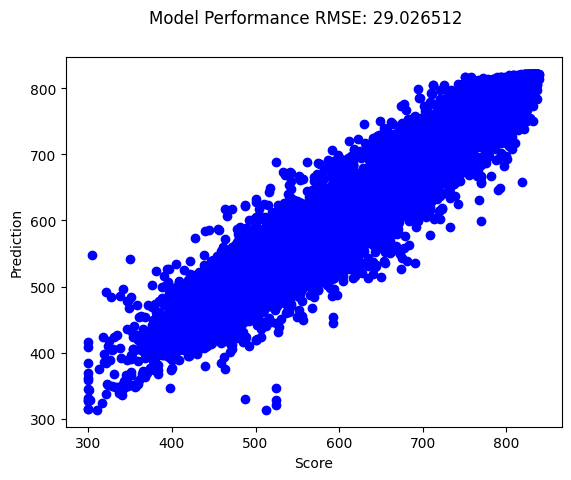

In [ ]:
rfPred = model.transform(test_df)
rfResult = rfPred.toPandas()

plt.plot(rfResult.label, rfResult.prediction, 'bo')
plt.xlabel('Score')
plt.ylabel('Prediction')
plt.suptitle("Model Performance RMSE: %f" % rmse)
plt.show()